# EDA — Part D: Duplicates, Label Noise & Non-Face Inspection

**Goal:** Hunt the subtler data problems that the earlier passes can't see:
1. **Exact duplicates** — identical images, especially across splits (leakage).
2. **Conflicting labels** — the same image tagged with two different emotions
   (a direct, measurable signal of label noise).
3. **Mislabels / non-faces** — rows that aren't really faces, spotted by eye.
4. **Near-duplicates** — images that are nearly identical after downscaling.

**Why it matters (CONTRIBUTING.md §7, §8):**
- **Cross-split duplicates inflate scores.** If a training image also sits in the
  test set, the model has effectively seen the answer — reported accuracy is a lie.
- **Label noise caps achievable accuracy.** No model can exceed the fraction of
  correctly-labelled data. This is partly *why* the project target is >60%, not >95%.
- **We accept some noise** rather than over-cleaning (which risks throwing away
  legitimately hard examples).

Duplicate handling becomes the toggle `config.yaml → cleaning.remove_duplicates`
(`true | false`), decided in the cleaning discussion (#16).

## 0. Setup

In [9]:
import sys
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path().resolve().parent  # notebooks/ → project root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.emotion_detector.utils.config import load_config
from src.emotion_detector.utils.logging import setup_logging
from src.emotion_detector.data.fer2013 import Fer2013Fetcher

cfg = load_config(ROOT / "config.yaml")
for key in cfg["paths"]:
    cfg["paths"][key] = str(ROOT / cfg["paths"][key])
setup_logging(cfg)

SEED = cfg["global"]["seed"]
rng = np.random.default_rng(SEED)

EDA_DIR = Path(cfg["paths"]["results_dir"]) / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

EMOTION_LABELS = {
    0: "Angry", 1: "Disgust", 2: "Fear",
    3: "Happy", 4: "Sad",     5: "Surprise", 6: "Neutral",
}
print(f"Seed = {SEED}; figures → {EDA_DIR}")

2026-07-04 13:28:30 | INFO     | src.emotion_detector.utils.logging:61 — Logging initialised — level=INFO, log_dir=/Users/mohammad.kheirkhah/Desktop/emotions-detecto/logs


Seed = 42; figures → /Users/mohammad.kheirkhah/Desktop/emotions-detecto/results/eda


## 1. Load all three splits and build a hash table

We fingerprint every image with **MD5 of its raw pixel bytes** (`array.tobytes()`).
Two images with the same fingerprint are byte-for-byte identical. We keep the
images per split so we can render suspects, and build one long DataFrame of
`(hash, emotion, split, idx)` for the duplicate analysis.

In [10]:
fetcher = Fer2013Fetcher(cfg)
splits = {}
for split in ("Training", "PublicTest", "PrivateTest"):
    imgs, labs = fetcher.fetch(split)
    splits[split] = {"images": imgs, "labels": labs}
    print(f"{split:12} {imgs.shape}")


def hash_image(img: np.ndarray) -> str:
    """MD5 fingerprint of an image's raw bytes — identical images share a hash."""
    return hashlib.md5(img.tobytes()).hexdigest()


frames = []
for split, d in splits.items():
    imgs, labs = d["images"], d["labels"]
    hashes = [hash_image(imgs[i]) for i in range(len(imgs))]
    frames.append(pd.DataFrame({
        "hash": hashes,
        "emotion": labs,
        "split": split,
        "idx": np.arange(len(imgs)),
    }))

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal images : {len(df):,}")
print(f"Unique hashes: {df['hash'].nunique():,}")
print(f"Exact duplicate rows (total − unique): {len(df) - df['hash'].nunique():,}")

2026-07-04 13:28:32 | INFO     | src.emotion_detector.data.fer2013:89 — Loading split 'Training': 28,709 rows from icml_face_data.csv
2026-07-04 13:28:34 | INFO     | src.emotion_detector.data.fer2013:104 — Split 'Training' ready — images (28709, 48, 48) uint8, labels (28709,)


Training     (28709, 48, 48)


2026-07-04 13:28:36 | INFO     | src.emotion_detector.data.fer2013:89 — Loading split 'PublicTest': 3,589 rows from icml_face_data.csv
2026-07-04 13:28:37 | INFO     | src.emotion_detector.data.fer2013:104 — Split 'PublicTest' ready — images (3589, 48, 48) uint8, labels (3589,)


PublicTest   (3589, 48, 48)


2026-07-04 13:28:39 | INFO     | src.emotion_detector.data.fer2013:89 — Loading split 'PrivateTest': 3,589 rows from icml_face_data.csv
2026-07-04 13:28:39 | INFO     | src.emotion_detector.data.fer2013:104 — Split 'PrivateTest' ready — images (3589, 48, 48) uint8, labels (3589,)


PrivateTest  (3589, 48, 48)

Total images : 35,887
Unique hashes: 34,034
Exact duplicate rows (total − unique): 1,853


## 2. Exact duplicates — within and across splits

`groupby(hash)` clusters identical images. A cluster of size > 1 is a duplicate
group. We break the count down by how many *distinct splits* each hash touches.

In [11]:
grp = df.groupby("hash")
cluster_size   = grp.size()
splits_touched = grp["split"].nunique()

dup_hashes = cluster_size[cluster_size > 1].index
print(f"Duplicate groups (hash appears > once): {len(dup_hashes):,}")
print(f"Images involved in a duplicate group  : {int(cluster_size[cluster_size > 1].sum()):,}")
print()

# Per-split internal duplicate counts (same image repeated inside one split).
print("Duplicate rows within each split:")
for split in ("Training", "PublicTest", "PrivateTest"):
    sub = df[df["split"] == split]
    dup_within = len(sub) - sub["hash"].nunique()
    print(f"  {split:12} {dup_within:>6,}")

Duplicate groups (hash appears > once): 1,516
Images involved in a duplicate group  : 3,369

Duplicate rows within each split:
  Training      1,236
  PublicTest       26
  PrivateTest      17


## 3. Cross-split duplicates — the leakage risk ⚠️

These are the dangerous ones: the **same image in two different splits**. If a
training image also appears in PublicTest/PrivateTest, the model is evaluated on
data it trained on, inflating the reported metric.

In [12]:
cross_hashes = splits_touched[splits_touched > 1].index
print(f"Cross-split duplicate images (leakage): {len(cross_hashes):,}")

if len(cross_hashes) > 0:
    # Which split-pairs leak, and how much?
    pair_counts = {}
    for h in cross_hashes:
        involved = tuple(sorted(df.loc[df["hash"] == h, "split"].unique()))
        pair_counts[involved] = pair_counts.get(involved, 0) + 1
    print("\nLeakage by split combination:")
    for combo, cnt in sorted(pair_counts.items(), key=lambda kv: -kv[1]):
        print(f"  {' + '.join(combo):40} {cnt:>5,}")
else:
    print("✓ No cross-split duplicates — no train/test leakage from exact copies.")

Cross-split duplicate images (leakage): 557

Leakage by split combination:
  PrivateTest + Training                     261
  PublicTest + Training                      253
  PrivateTest + PublicTest                    26
  PrivateTest + PublicTest + Training         17


Saved: /Users/mohammad.kheirkhah/Desktop/emotions-detecto/results/eda/leakage_examples.png


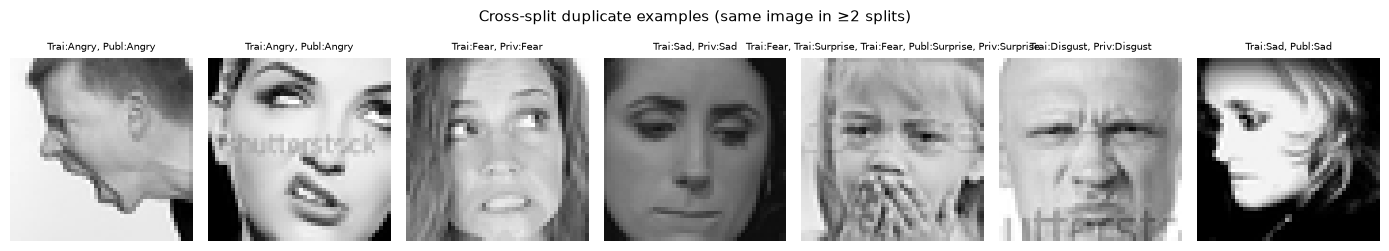

In [13]:
# Render a few cross-split leakage examples (one representative image per cluster).
if len(cross_hashes) > 0:
    show = list(cross_hashes[:7])
    fig, axes = plt.subplots(1, len(show), figsize=(len(show) * 2.0, 2.6))
    axes = np.atleast_1d(axes).ravel()
    for ax, h in zip(axes, show):
        rows = df[df["hash"] == h]
        first = rows.iloc[0]
        img = splits[first["split"]]["images"][first["idx"]]
        where = ", ".join(f"{r.split[:4]}:{EMOTION_LABELS[r.emotion]}" for r in rows.itertuples())
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_title(where, fontsize=7)
        ax.axis("off")
    fig.suptitle("Cross-split duplicate examples (same image in ≥2 splits)", fontsize=11)
    plt.tight_layout()
    fig.savefig(EDA_DIR / "leakage_examples.png", dpi=120, bbox_inches="tight")
    print(f"Saved: {EDA_DIR / 'leakage_examples.png'}")
    plt.show()
else:
    print("Nothing to render — no cross-split duplicates.")

## 4. Conflicting-label duplicates — a measurable label-noise signal

If the **same pixels** carry **two different emotion labels**, at least one label
is wrong. This is the one slice of label noise we can detect automatically (the
rest requires human judgement, §5).

Images with conflicting labels: 57
Saved: /Users/mohammad.kheirkhah/Desktop/emotions-detecto/results/eda/conflicting_labels.png


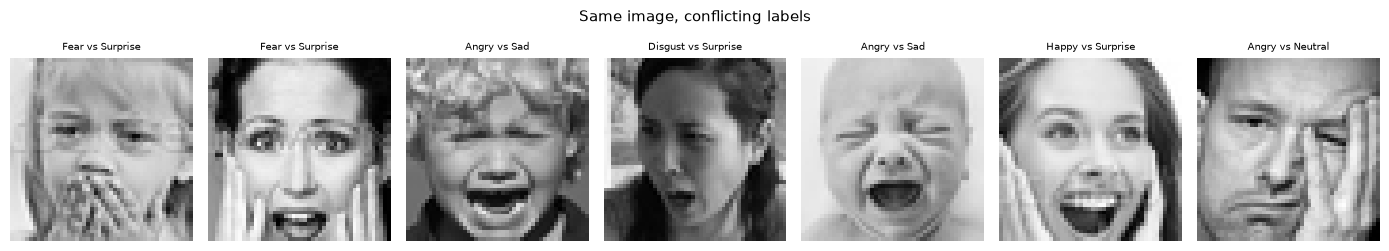

In [14]:
labels_per_hash = grp["emotion"].nunique()
conflict_hashes = labels_per_hash[labels_per_hash > 1].index
print(f"Images with conflicting labels: {len(conflict_hashes):,}")

if len(conflict_hashes) > 0:
    show = list(conflict_hashes[:7])
    fig, axes = plt.subplots(1, len(show), figsize=(len(show) * 2.0, 2.6))
    axes = np.atleast_1d(axes).ravel()
    for ax, h in zip(axes, show):
        rows = df[df["hash"] == h]
        first = rows.iloc[0]
        img = splits[first["split"]]["images"][first["idx"]]
        emotions = " vs ".join(sorted({EMOTION_LABELS[e] for e in rows["emotion"]}))
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_title(emotions, fontsize=7)
        ax.axis("off")
    fig.suptitle("Same image, conflicting labels", fontsize=11)
    plt.tight_layout()
    fig.savefig(EDA_DIR / "conflicting_labels.png", dpi=120, bbox_inches="tight")
    print(f"Saved: {EDA_DIR / 'conflicting_labels.png'}")
    plt.show()
else:
    print("✓ No exact-duplicate images with conflicting labels.")

## 5. Spot-check for mislabels & non-faces

Automated detection can't catch a face that's simply labelled wrong, or a crop
that isn't a face. We render a seeded random sample per class and eyeball it.
Note anything that clearly isn't the labelled emotion, or isn't a face at all.

Saved: /Users/mohammad.kheirkhah/Desktop/emotions-detecto/results/eda/spotcheck_per_class.png


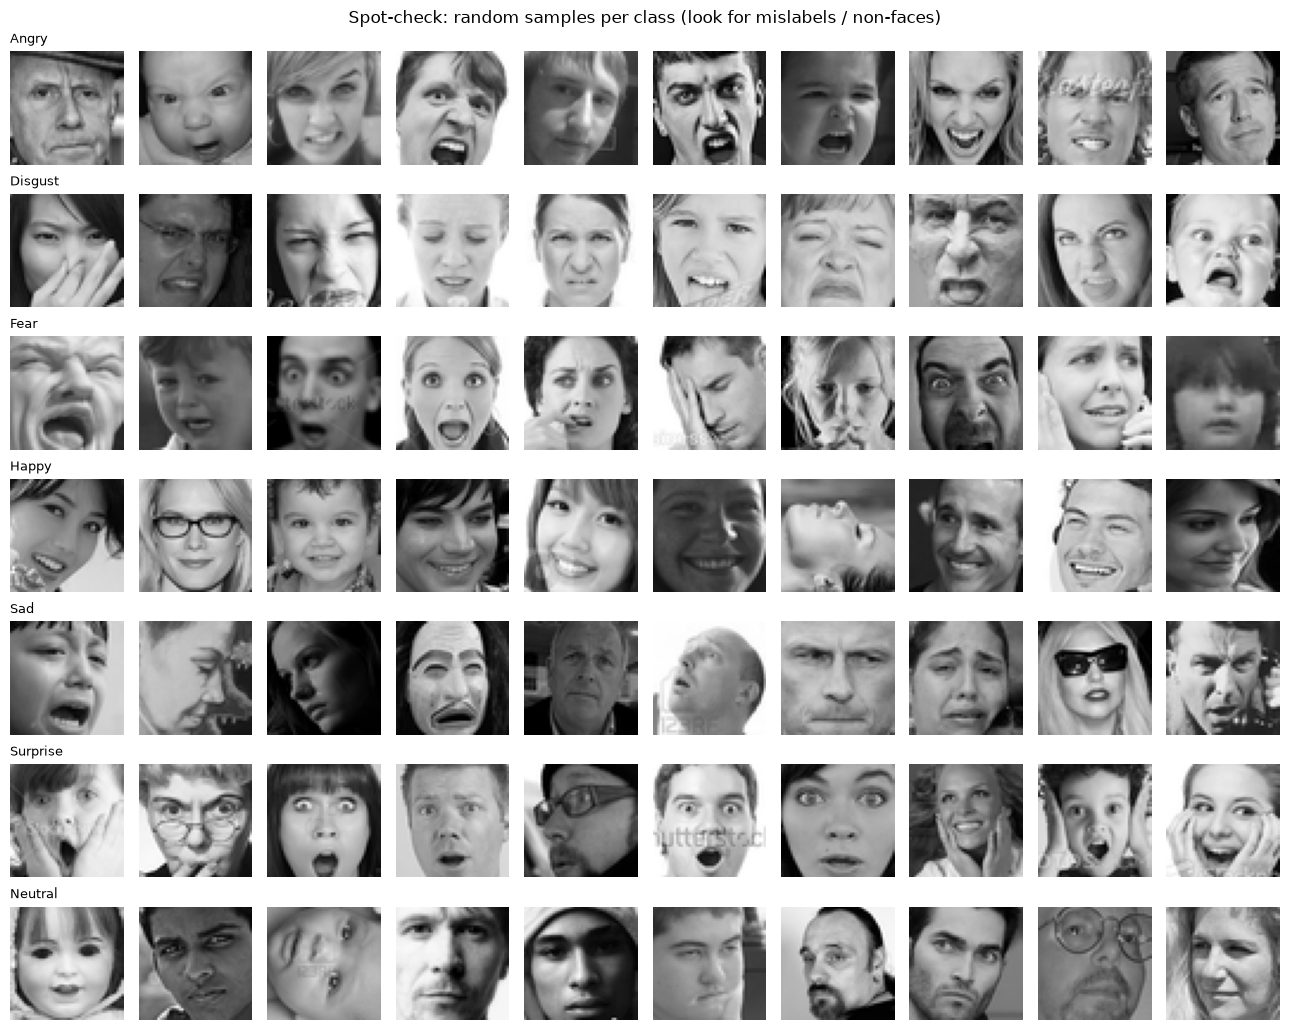

In [15]:
train_imgs = splits["Training"]["images"]
train_labs = splits["Training"]["labels"]

per_class = 10
rows, cols = len(EMOTION_LABELS), per_class
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.5))
for r, code in enumerate(sorted(EMOTION_LABELS)):
    class_idx = np.where(train_labs == code)[0]
    picks = rng.choice(class_idx, size=per_class, replace=False)
    for c, i in enumerate(picks):
        axes[r, c].imshow(train_imgs[i], cmap="gray", vmin=0, vmax=255)
        axes[r, c].axis("off")
    axes[r, 0].set_title(EMOTION_LABELS[code], fontsize=9, loc="left")
fig.suptitle("Spot-check: random samples per class (look for mislabels / non-faces)", fontsize=12)
plt.tight_layout()
fig.savefig(EDA_DIR / "spotcheck_per_class.png", dpi=120, bbox_inches="tight")
print(f"Saved: {EDA_DIR / 'spotcheck_per_class.png'}")
plt.show()

## 6. (Optional) Near-duplicate detection via average hash (aHash)

Exact hashing misses images that differ by a single pixel. **Average hash**
downscales each image to an 8×8 grid and records which cells are above the
image's mean — a 64-bit perceptual fingerprint. Images that look nearly
identical collide on this fingerprint even if their raw bytes differ.

In [16]:
def average_hash(images: np.ndarray) -> list[bytes]:
    """Vectorized 8x8 average hash. images: (N,48,48) uint8 → list of 8-byte keys.

    48 = 8*6, so we block-average each 6x6 tile into one of 8x8 super-pixels,
    then threshold each super-pixel against the per-image mean.
    """
    n = len(images)
    small = images.reshape(n, 8, 6, 8, 6).mean(axis=(2, 4))       # (N,8,8)
    bits = small >= small.mean(axis=(1, 2), keepdims=True)         # (N,8,8) bool
    packed = np.packbits(bits.reshape(n, 64), axis=1)              # (N,8) uint8
    return [row.tobytes() for row in packed]


# Run on the training split (cheap, O(N)).
ahashes = average_hash(train_imgs)
ah = pd.Series(ahashes)
near_clusters = ah.value_counts()
near_clusters = near_clusters[near_clusters > 1]

exact_within_train = len(train_imgs) - pd.Series([hash_image(train_imgs[i]) for i in range(len(train_imgs))]).nunique()
print(f"Training images                         : {len(train_imgs):,}")
print(f"Exact-duplicate rows (MD5)              : {exact_within_train:,}")
print(f"Near-duplicate aHash clusters (size>1)  : {len(near_clusters):,}")
print(f"Images in a near-dup cluster            : {int(near_clusters.sum()):,}")
print("\nNote: aHash is coarse (8x8) — some collisions are genuinely different")
print("faces that happen to share a low-res silhouette. Treat as an upper bound.")

Training images                         : 28,709
Exact-duplicate rows (MD5)              : 1,236
Near-duplicate aHash clusters (size>1)  : 1,176
Images in a near-dup cluster            : 2,621

Note: aHash is coarse (8x8) — some collisions are genuinely different
faces that happen to share a low-res silhouette. Treat as an upper bound.


## 7. Findings for `data.md` §2 & cleaning (#16)

Fill the **Result** column from the outputs above after running on the real data.

| Finding | Result | Cleaning action |
|---|---|---|
| Exact-duplicate groups (MD5) | — | `cleaning.remove_duplicates` |
| Duplicate rows within Training | — | drop keeps one copy |
| **Cross-split duplicates (leakage)** | — | **must drop** — dedup before/at split |
| Conflicting-label duplicates | — | drop or relabel; evidence of label noise |
| Near-duplicate aHash clusters | — | optional; usually kept (over-cleaning risk) |
| Obvious mislabels / non-faces (eyeball) | — | accept — too costly to hand-clean 35k |

**Decisions to carry into #16 (learning-loop discussion):**
- **Cross-split duplicates → always remove.** Leakage makes the test metric
  dishonest; this is non-negotiable (CONTRIBUTING §8).
- **Within-split exact duplicates → drop by default** (`cleaning.remove_duplicates:
  true`) so a repeated image doesn't get extra weight, but keep it a toggle to
  ablate the effect.
- **Label noise → accept the residual.** It caps achievable accuracy (part of why
  the target is >60%), but hand-relabelling 35k images is out of scope. We fight
  it with early stopping (don't memorise noisy labels) and honest metrics
  (macro-F1, per-class recall) rather than perfect data.
- **Near-duplicates & non-faces → note but keep.** Over-cleaning discards hard
  examples the model should learn from; the cost/benefit doesn't justify it.